The Scope of this project:

Given price data for crude oil, natural gas and copper - we want to find out how these markets relate to each other, how volatile are they and what the underlying drivers of their co-movement are.

The idea is to extract raw prices from yfinance, produce the log returns of these prices, compute rolling volatiltiy & a correlation heatmap to finally produce a PCA result to visualise the first principal component.

In [29]:
import sys
sys.path.append('..')

%load_ext autoreload
%autoreload 2

from src.data_loader import TICKERS, load_or_fetch_prices
from src.analytics import compute_log_returns, compute_rolling_volatility, compute_correlation_matrix, run_pca, rebase_prices
from src.visualisation import plot_prices, plot_log_returns, plot_correlation_heatmap, plot_pca_summary, plot_rolling_volatility
from pathlib import Path

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Firstly, we extract the price data from Yfinance and loaded it into a pandas dataframe

In [44]:
prices = load_or_fetch_prices(
    tickers=TICKERS,
    start="2020-01-01",
    end="2026-05-01",
    cache_path=Path("../data/commodity_prices.csv")
)

print(prices.head())
print(prices.shape)

[*********************100%***********************]  3 of 3 completed

            Crude_Oil  Natural_Gas  Copper
Date                                      
2020-01-02  61.180000       2.8330   2.122
2020-01-03  63.049999       2.7985   2.130
2020-01-06  63.270000       2.8005   2.135
2020-01-07  62.700001       2.8040   2.162
2020-01-08  59.610001       2.8190   2.141
(1593, 3)


In [47]:
rebased_prices = rebase_prices(prices)
log_returns = compute_log_returns(prices)
rolling_vol = compute_rolling_volatility(log_returns)
corr_matrix = compute_correlation_matrix(log_returns)
pca_results = run_pca(log_returns, n_components=3)

c:\Users\addzz\Desktop\Code\quant-projects-roadmap\commodity-price-dashboard\venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


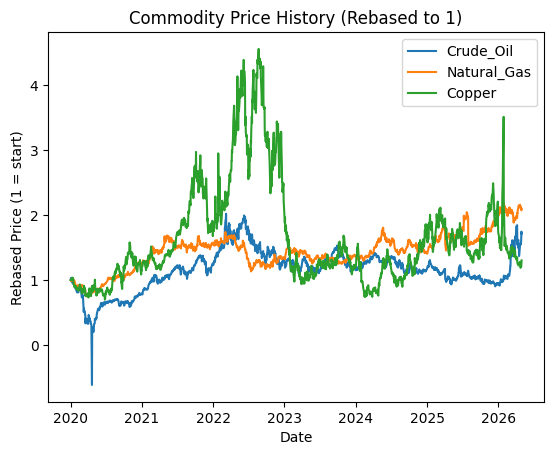

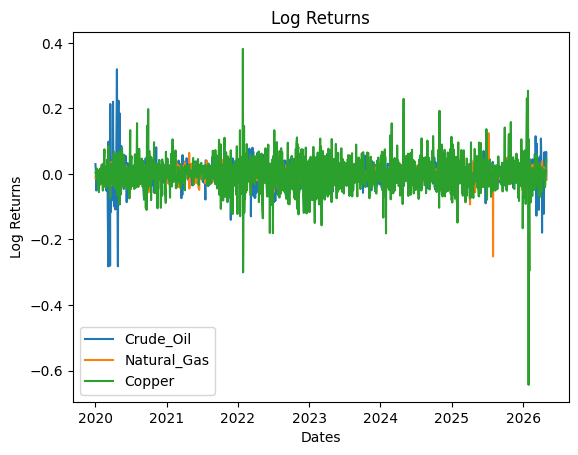

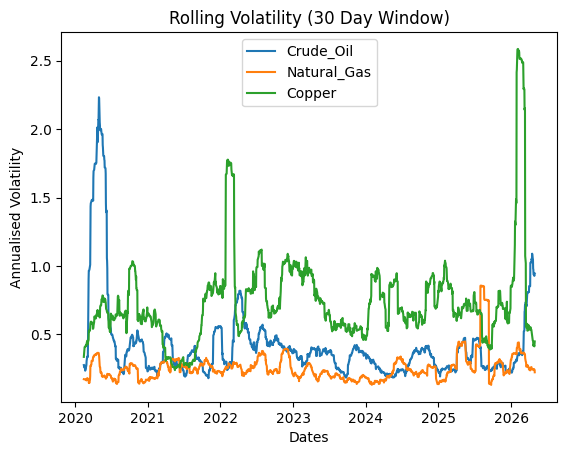

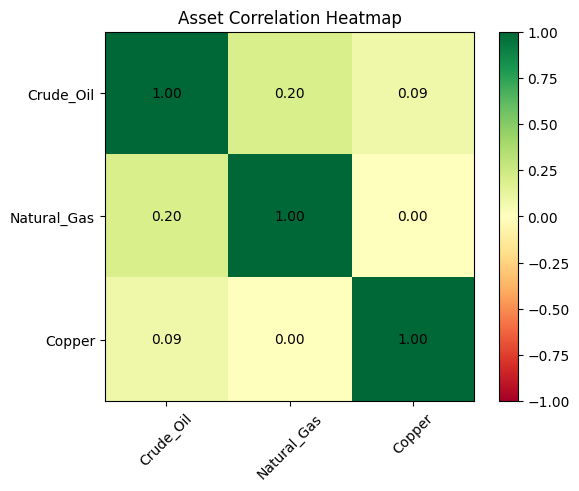

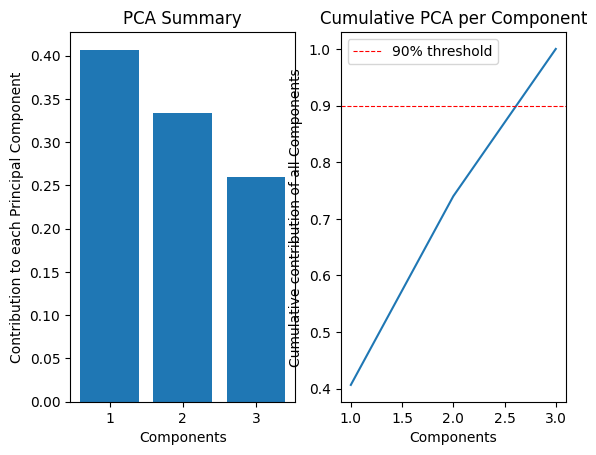

In [48]:
_=plot_prices(rebased_prices)
_=plot_log_returns(log_returns)
_=plot_rolling_volatility(rolling_vol)
_=plot_correlation_heatmap(corr_matrix)
_=plot_pca_summary(pca_results)